In [1]:
import json
from test import test_model
import torch
from glob import glob
import random
import pandas as pd
from model import Encoder, Decoder
import torch.nn as nn
from monai.inferers import SlidingWindowInferer
import matplotlib.pyplot as plt
from easydict import EasyDict as edict
from dataset import get_dataloader

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-zvjsp2j7 because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
MODEL_PATH = 'reports/ae_best.pth'
with open("config/train_no_sw.json", "r") as f:
    cfg = edict(json.load(f))

In [3]:
# Load model
checkpoint = torch.load(MODEL_PATH, weights_only=True)

encoder = Encoder(cfg.img_size[0], cfg.img_size[1], cfg.img_size[2], z_dim=512).to(cfg.device)
decoder = Decoder(cfg.img_size[0], cfg.img_size[1], cfg.img_size[2], z_dim=512).to(cfg.device)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

<All keys matched successfully>

In [10]:
train_loader = get_dataloader(cfg, mode="test")

In [13]:
for data in train_loader:
    img = data['im'].to(cfg.device)
    # ==========forward=========
    z = encoder(img)
    x_hat = decoder(z)
    break

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


## Visualize

Running smoke-test on: cuda


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Figure saved → prelim_results/recons_orig/slice_comparison.png
Done. Figure written to /tmp/slice_comparison.png


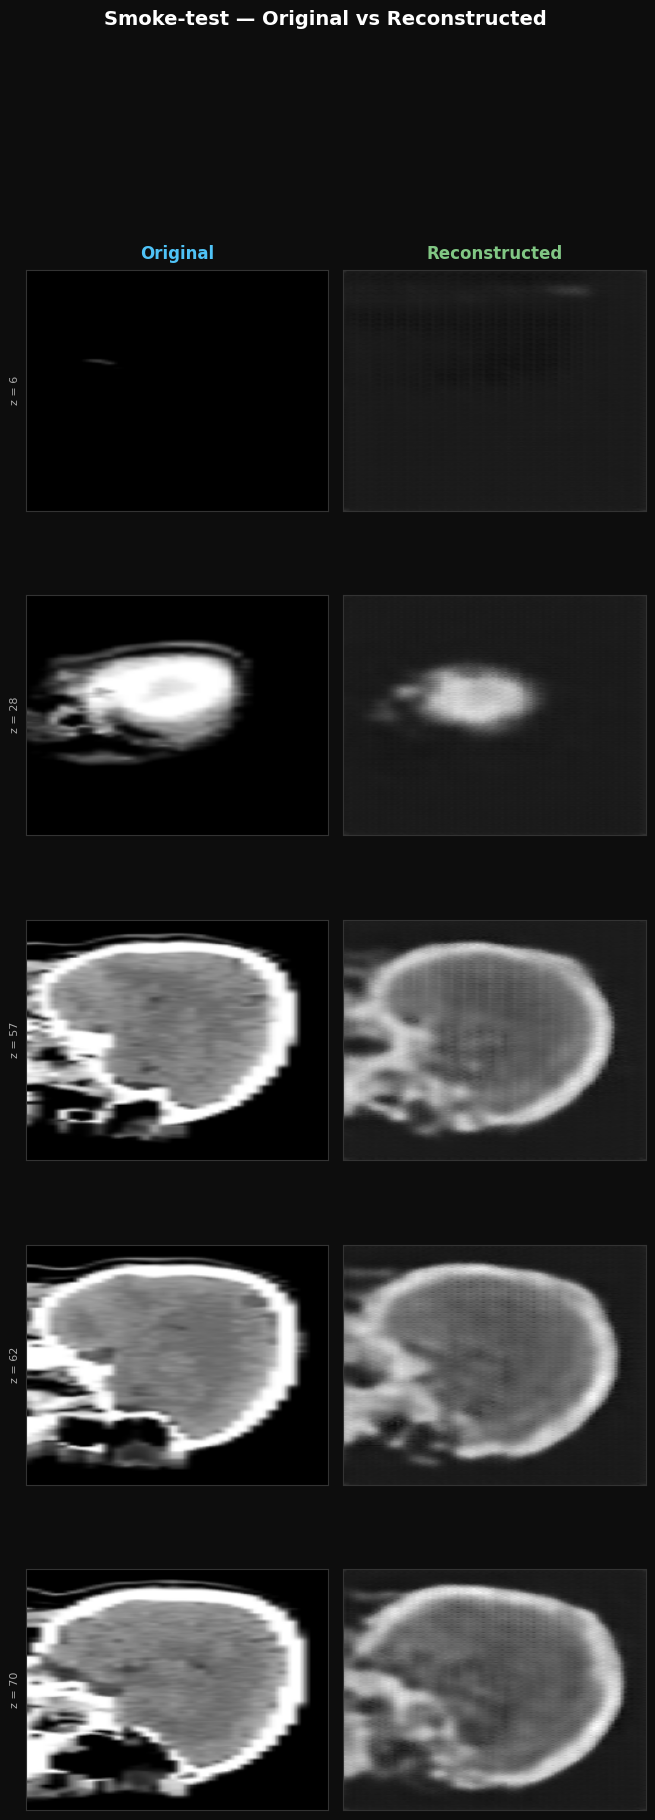

In [14]:
from vis_module import visualize_slices


# ── quick smoke-test ───────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running smoke-test on: {device}")

# Simulate a (B=1, C=1, D=64, H=128, W=128) pair
orig  = torch.rand(1, 1, 64, 128, 128, device=device)
recon = orig + 0.05 * torch.randn_like(orig)   # slight noise

fig = visualize_slices(
    img,
    x_hat,
    n_slices=5,
    suptitle="Smoke-test — Original vs Reconstructed",
    save_path="prelim_results/recons_orig/slice_comparison.png",
    seed=42,
)
print("Done. Figure written to /tmp/slice_comparison.png")




In [12]:
data['im_meta_dict']['filename_or_obj']

['/home/jovyan/imgs/Physionet/physionet_scans/ct_scans/082.nii']

In [15]:
from inference_utils import save_nii

save_nii(x_hat, 'prelim_results/physionet_082_recons.nii.gz')